# Easy Run Daily HR Smoothness Notebook

This notebook parses all easy-run FIT files, draws one HR graph per run/day, and computes a smoothness score (0-100) for each run.

Smoothness score idea:
- Build a rolling-median HR baseline.
- Measure short-term HR noise around that baseline.
- Normalize by the run's HR dynamic range.
- Convert to a 0-100 score (higher = smoother curve).

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make sure we can import project modules when notebook is run from notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.fit_parser import FitParser

In [2]:
EASY_DIR = PROJECT_ROOT / "data" / "activities" / "easy" / "raw"
fit_files = sorted(EASY_DIR.glob("*.fit"))

print(f"Easy run folder: {EASY_DIR}")
print(f"FIT files found: {len(fit_files)}")
for f in fit_files:
    print("-", f.name)

Easy run folder: C:\Users\A717631\repo\theEagle\data\activities\easy\raw
FIT files found: 20
- 2026-04-16_thursday_easy.fit
- 2026-04-18_saturday_easy.fit
- 2026-04-23_thursday_easy.fit
- 2026-04-25_saturday_easy.fit
- 2026-04-30_thursday_easy.fit
- 2026-05-02_saturday_easy.fit
- 2026-05-09_saturday_easy.fit
- 2026-05-14_thursday_easy.fit
- 2026-05-21_thursday_easy.fit
- 2026-05-23_saturday_easy.fit
- 2026-05-28_thursday_easy.fit
- 2026-06-02_tuesday_easy.fit
- 2026-06-04_thursday_easy.fit
- 2026-06-13_saturday_easy.fit
- 2026-06-16_tuesday_easy.fit
- 2026-06-23_tuesday_easy.fit
- 2026-06-30_tuesday_easy.fit
- 2026-07-04_saturday_easy.fit
- 2026-07-07_tuesday_easy.fit
- 2026_05_07_thursday_easy.fit


In [3]:
def compute_hr_smoothness_score(hr_series: pd.Series, window: int = 15) -> float:
    """Return HR smoothness score in [0, 100]. Higher means smoother."""
    hr = pd.to_numeric(hr_series, errors="coerce").dropna().reset_index(drop=True)
    if len(hr) < 60:
        return float("nan")

    baseline = hr.rolling(window=window, center=True, min_periods=1).median()
    noise = float((hr - baseline).std())

    dynamic = float(baseline.quantile(0.95) - baseline.quantile(0.05))
    # Protect denominator for very flat sessions.
    denom = max(2.0, 0.25 * dynamic)

    score = 100.0 * (1.0 - (noise / denom))
    return float(np.clip(score, 0.0, 100.0))


def score_band(score: float) -> str:
    if pd.isna(score):
        return "insufficient_data"
    if score >= 80:
        return "very_smooth"
    if score >= 65:
        return "smooth"
    if score >= 50:
        return "moderate"
    return "noisy"

In [4]:

runs = []

for fit_path in fit_files:
    parser = FitParser(fit_path)
    parser.parse()

    rec = parser.records.copy()
    if rec.empty or "timestamp" not in rec.columns or "heart_rate" not in rec.columns:
        continue

    rec["timestamp"] = pd.to_datetime(rec["timestamp"], errors="coerce")
    rec["heart_rate"] = pd.to_numeric(rec["heart_rate"], errors="coerce")
    rec = rec.dropna(subset=["timestamp", "heart_rate"]).sort_values("timestamp")

    if rec.empty:
        continue

    session_df = parser.session.copy()
    session_row = session_df.iloc[0] if not session_df.empty else pd.Series(dtype=float)

    avg_speed = pd.to_numeric(
        session_row.get("enhanced_avg_speed", session_row.get("avg_speed", np.nan)),
        errors="coerce",
    )
    avg_pace = np.nan if pd.isna(avg_speed) or avg_speed <= 0 else 1000.0 / (avg_speed * 60.0)

    total_distance_m = pd.to_numeric(session_row.get("total_distance", np.nan), errors="coerce")
    total_distance_km = np.nan if pd.isna(total_distance_m) else total_distance_m / 1000.0

    avg_hr_bpm = pd.to_numeric(session_row.get("avg_heart_rate", np.nan), errors="coerce")
    if pd.isna(avg_hr_bpm):
        avg_hr_bpm = rec["heart_rate"].mean()

    # Power: try session avg_power first, then per-record mean.
    avg_power_w = pd.to_numeric(session_row.get("avg_power", np.nan), errors="coerce")
    if pd.isna(avg_power_w) and "power" in rec.columns:
        pwr = pd.to_numeric(rec["power"], errors="coerce").dropna()
        avg_power_w = float(pwr.mean()) if not pwr.empty else np.nan

    temp_distribution = "no_temperature_data"
    if "temperature" in rec.columns:
        temp_series = pd.to_numeric(rec["temperature"], errors="coerce").dropna()
        if not temp_series.empty:
            counts = temp_series.round().astype(int).value_counts().sort_index()
            pct = (counts / counts.sum() * 100).round(1)
            temp_distribution = ", ".join([f"{t}°C: {p}%" for t, p in pct.items()])

    run_date = rec["timestamp"].iloc[0].date()
    score = compute_hr_smoothness_score(rec["heart_rate"])

    runs.append({
        "file": fit_path.name,
        "date": pd.Timestamp(run_date),
        "records": rec,
        "avg_pace_min_per_km": avg_pace,
        "total_distance_km": total_distance_km,
        "avg_hr_bpm": avg_hr_bpm,
        "avg_power_w": avg_power_w,
        "temperature_distribution": temp_distribution,
        "hr_smoothness_score": score,
        "score_band": score_band(score),
    })

runs_df = pd.DataFrame([{
    "date": r["date"],
    "file": r["file"],
    "avg_pace_min_per_km": r["avg_pace_min_per_km"],
    "total_distance_km": r["total_distance_km"],
    "avg_hr_bpm": r["avg_hr_bpm"],
    "avg_power_w": r["avg_power_w"],
    "temperature_distribution": r["temperature_distribution"],
    "hr_smoothness_score": r["hr_smoothness_score"],
    "score_band": r["score_band"],
} for r in runs]).sort_values("date").reset_index(drop=True)

runs_df


,date,file,avg_pace_min_per_km,total_distance_km,avg_hr_bpm,avg_power_w,temperature_distribution,hr_smoothness_score,score_band
0,2026-04-16,2026-04-16_thursday_easy.fit,7.473842,6.02534,148,230,no_temperature_data,91.918491,very_smooth
1,2026-04-18,2026-04-18_saturday_easy.fit,7.534659,7.00782,155,228,"30°C: 11.2%, 31°C: 64.1%, 32°C: 24.7%",91.988912,very_smooth
2,2026-04-23,2026-04-23_thursday_easy.fit,7.329229,6.14353,149,236,"29°C: 4.0%, 30°C: 72.3%, 31°C: 23.7%",90.169045,very_smooth
3,2026-04-25,2026-04-25_saturday_easy.fit,7.345380,5.00692,152,235,"30°C: 42.0%, 31°C: 45.4%, 32°C: 12.6%",90.943382,very_smooth
4,2026-04-30,2026-04-30_thursday_easy.fit,7.297140,8.24235,152,240,"30°C: 81.6%, 31°C: 18.4%",93.218515,very_smooth
5,2026-05-02,2026-05-02_saturday_easy.fit,7.322789,10.01050,150,237,"31°C: 48.2%, 32°C: 49.5%, 33°C: 2.3%",93.531629,very_smooth
6,2026-05-07,2026_05_07_thursday_easy.fit,7.335681,8.19346,149,231,"29°C: 6.5%, 30°C: 82.9%, 31°C: 10.6%",94.183949,very_smooth
7,2026-05-09,2026-05-09_saturday_easy.fit,7.345380,10.21530,147,232,"29°C: 64.0%, 30°C: 34.3%, 31°C: 1.7%",92.279147,very_smooth
8,2026-05-14,2026-05-14_thursday_easy.fit,7.490637,10.02703,150,226,"30°C: 53.1%, 31°C: 22.9%, 32°C: 24.0%",90.993554,very_smooth
9,2026-05-21,2026-05-21_thursday_easy.fit,7.335681,12.27638,151,234,"30°C: 2.0%, 31°C: 55.5%, 32°C: 41.7%, 33°C: 0.9%",91.671792,very_smooth


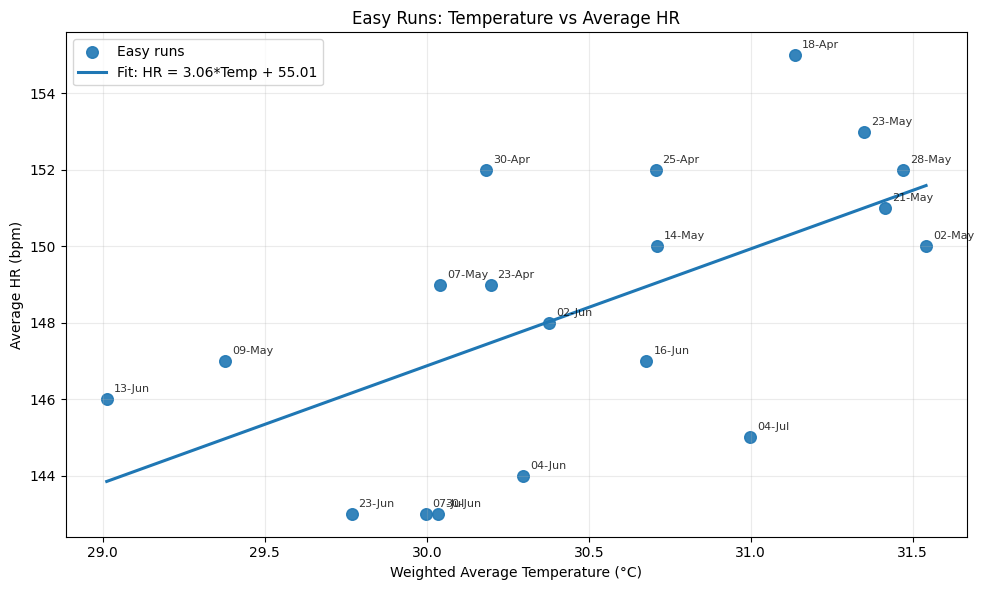

Runs plotted: 19
Approx correlation (Pearson r): 0.597
Estimated HR increase per +1°C: 3.06 bpm


In [5]:
# Graph: Weighted average temperature vs average HR (easy runs)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'runs_df' not in globals() or runs_df.empty:
    print('No run summary data found. Run the previous summary cell first.')
else:
    plot_df = runs_df.copy()

    # Parse strings like '30°C: 20%, 31°C: 80%' into a weighted average temperature.
    def weighted_temp_from_distribution(dist):
        if pd.isna(dist) or str(dist).strip().lower() == 'no_temperature_data':
            return np.nan
        pairs = re.findall(r'(-?\d+)\s*°C:\s*([0-9.]+)%', str(dist))
        if not pairs:
            return np.nan
        temps = np.array([float(t) for t, _ in pairs], dtype=float)
        pcts = np.array([float(p) for _, p in pairs], dtype=float)
        total = pcts.sum()
        return np.nan if total == 0 else float((temps * pcts).sum() / total)

    plot_df['weighted_avg_temp_c'] = plot_df['temperature_distribution'].apply(weighted_temp_from_distribution)
    plot_df = plot_df.dropna(subset=['weighted_avg_temp_c', 'avg_hr_bpm']).copy()

    if len(plot_df) < 2:
        print('Not enough valid runs to draw the relationship graph.')
    else:
        x = plot_df['weighted_avg_temp_c'].to_numpy(dtype=float)
        y = plot_df['avg_hr_bpm'].to_numpy(dtype=float)

        # Best-fit line: HR = m * Temp + b
        m, b = np.polyfit(x, y, 1)
        y_fit = m * x + b

        plt.figure(figsize=(10, 6))
        plt.scatter(x, y, s=70, alpha=0.9, label='Easy runs')
        order = np.argsort(x)
        plt.plot(x[order], y_fit[order], linewidth=2.2, label=f'Fit: HR = {m:.2f}*Temp + {b:.2f}')

        # Annotate each point with date for easy tracking.
        for _, row in plot_df.iterrows():
            label = pd.to_datetime(row['date']).strftime('%d-%b')
            plt.annotate(
                label,
                (row['weighted_avg_temp_c'], row['avg_hr_bpm']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                alpha=0.8,
            )

        plt.title('Easy Runs: Temperature vs Average HR')
        plt.xlabel('Weighted Average Temperature (°C)')
        plt.ylabel('Average HR (bpm)')
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

        corr = np.corrcoef(x, y)[0, 1]
        print(f'Runs plotted: {len(plot_df)}')
        print(f'Approx correlation (Pearson r): {corr:.3f}')
        print(f'Estimated HR increase per +1°C: {m:.2f} bpm')

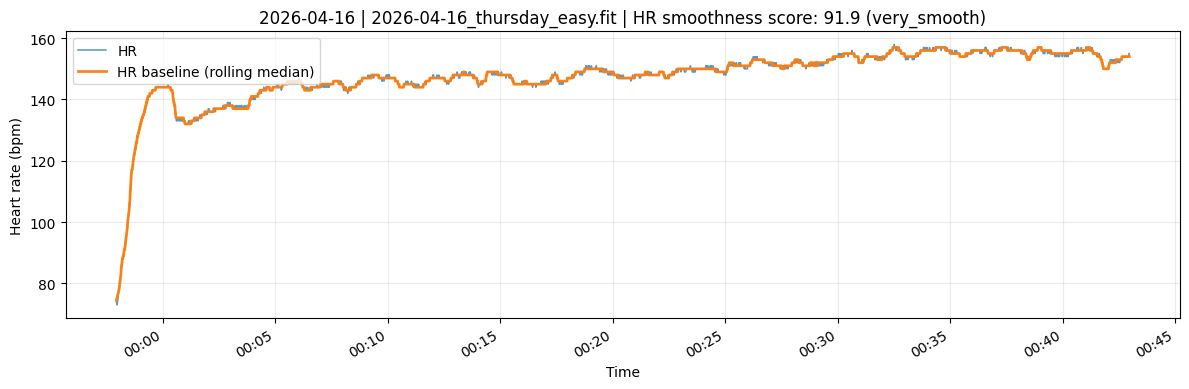

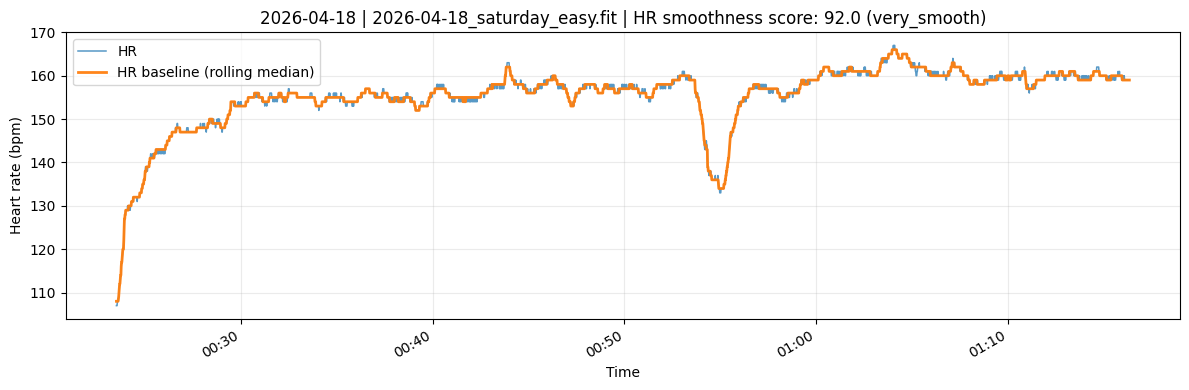

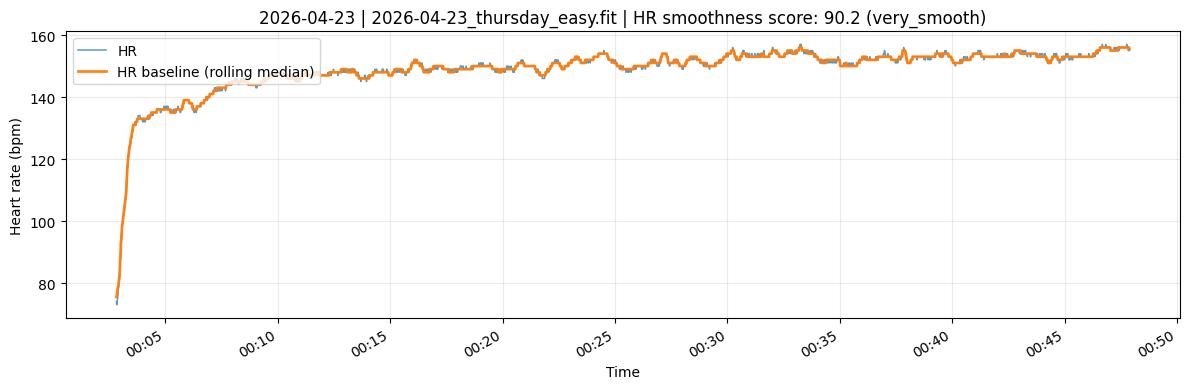

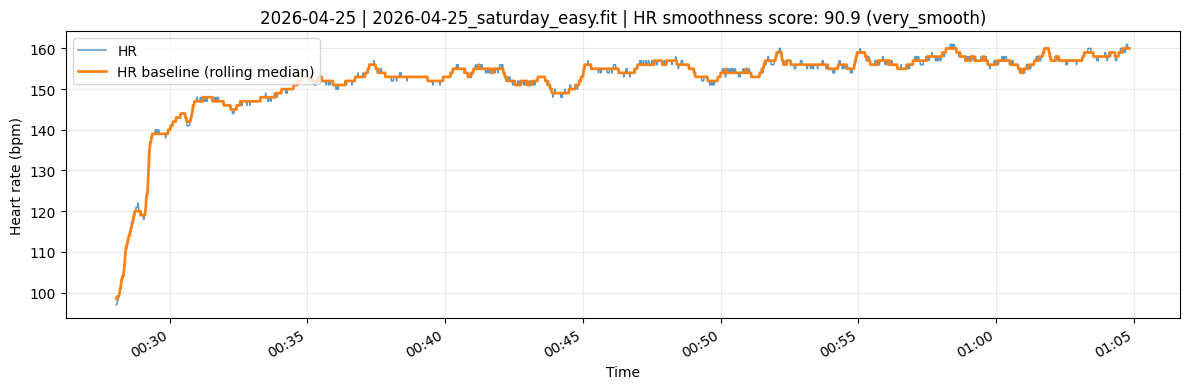

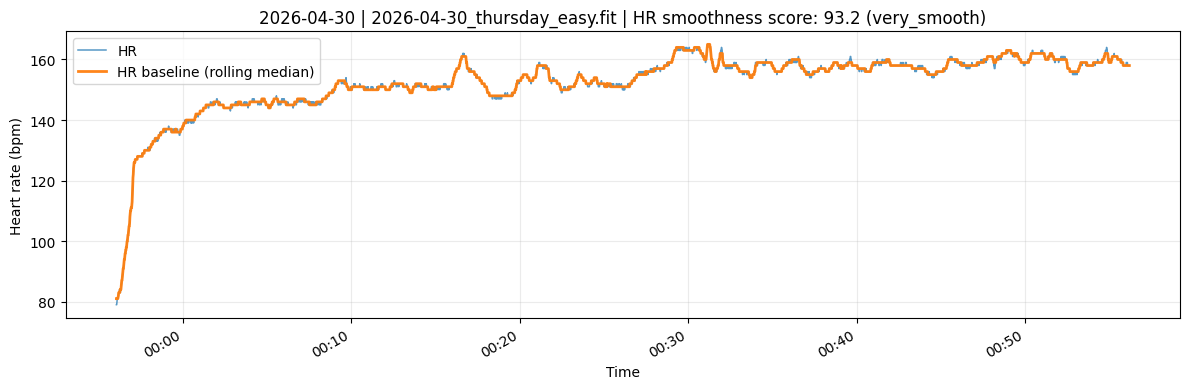

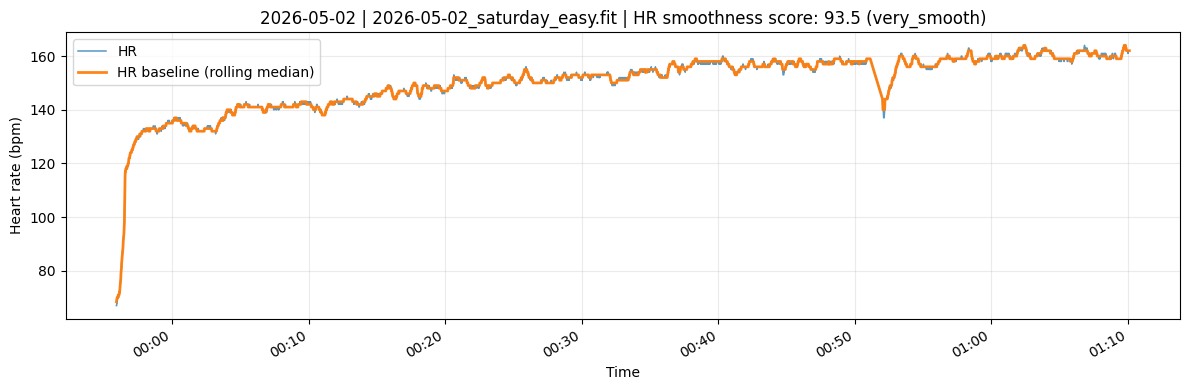

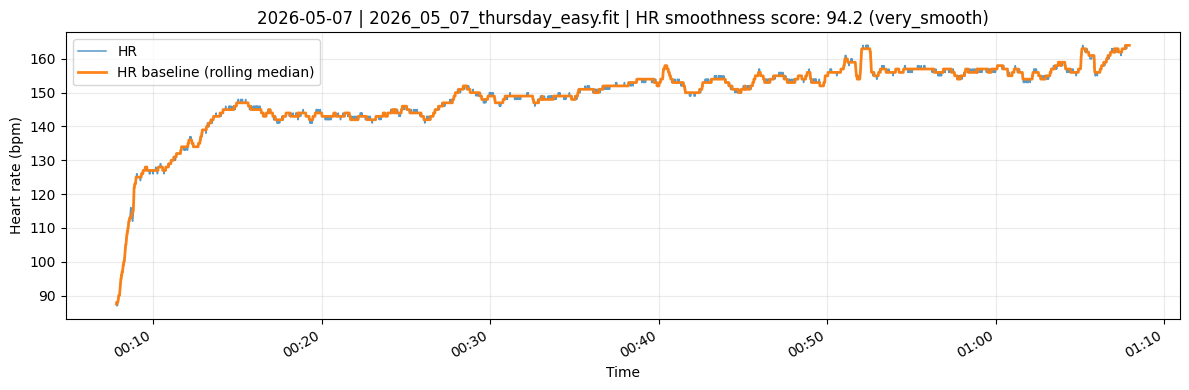

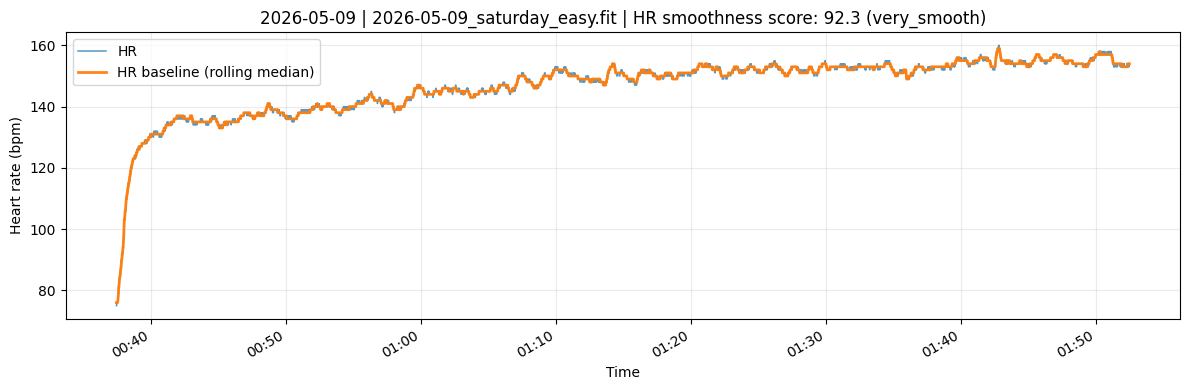

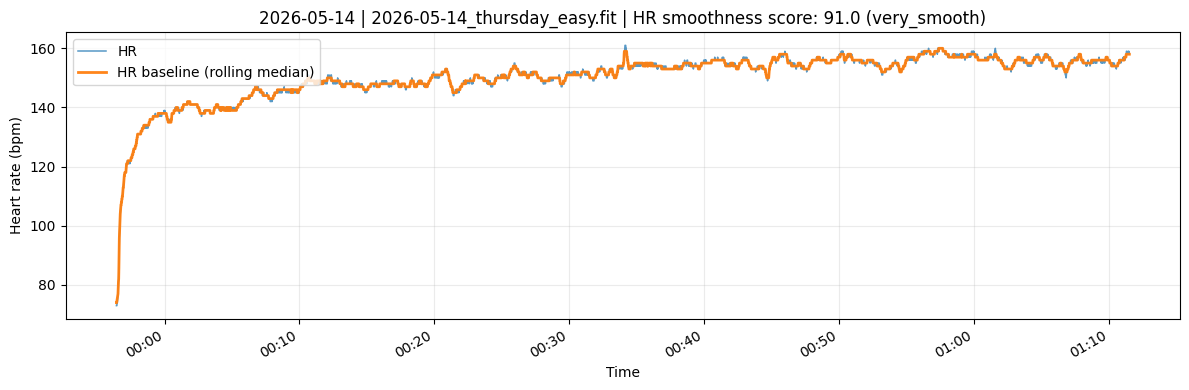

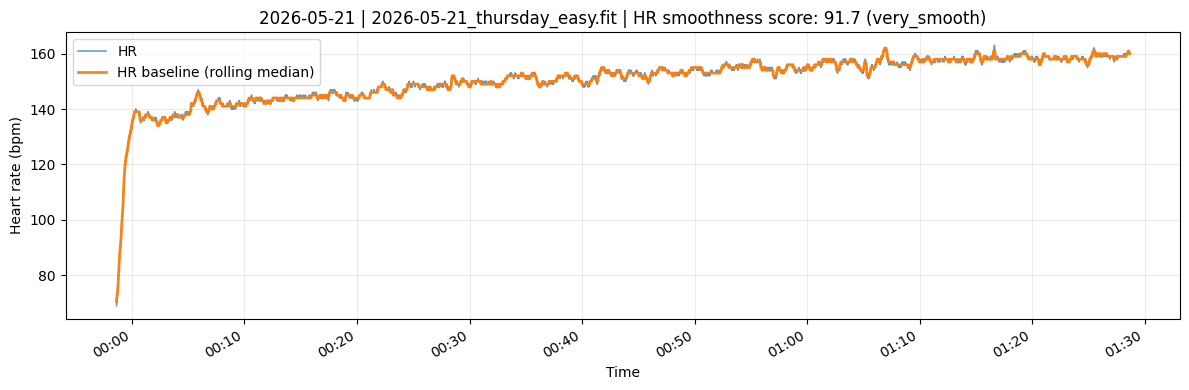

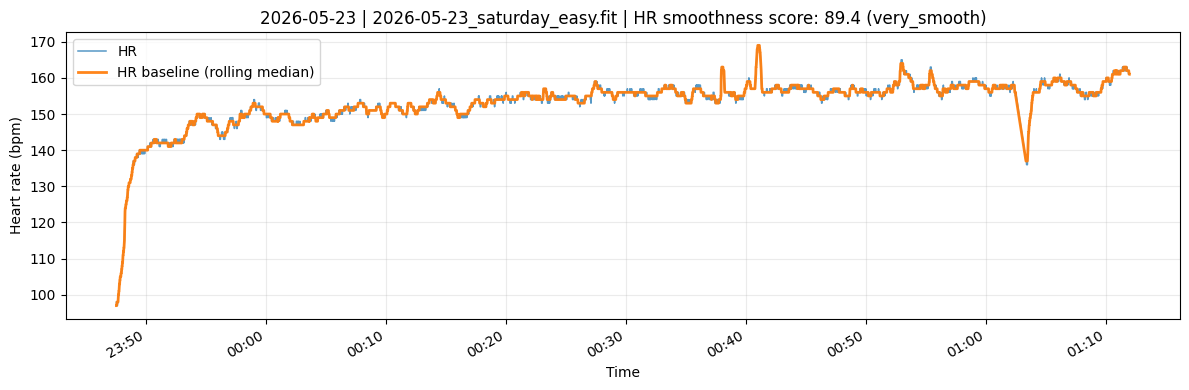

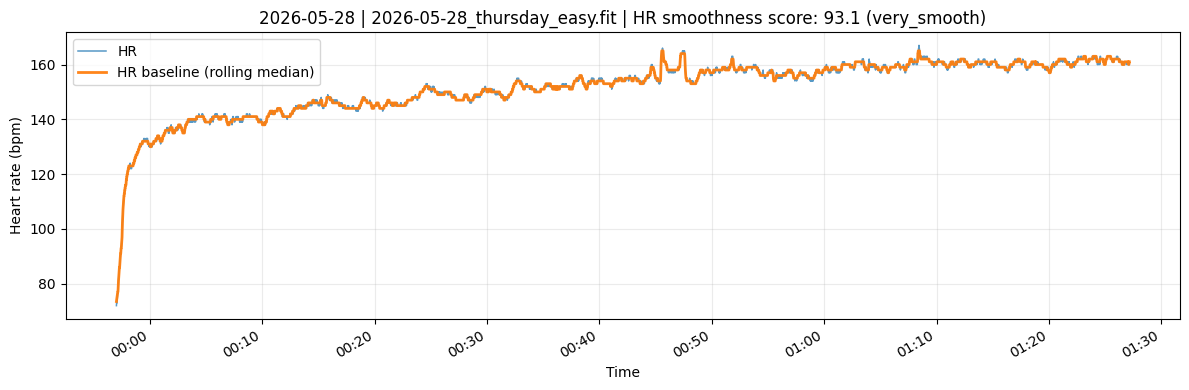

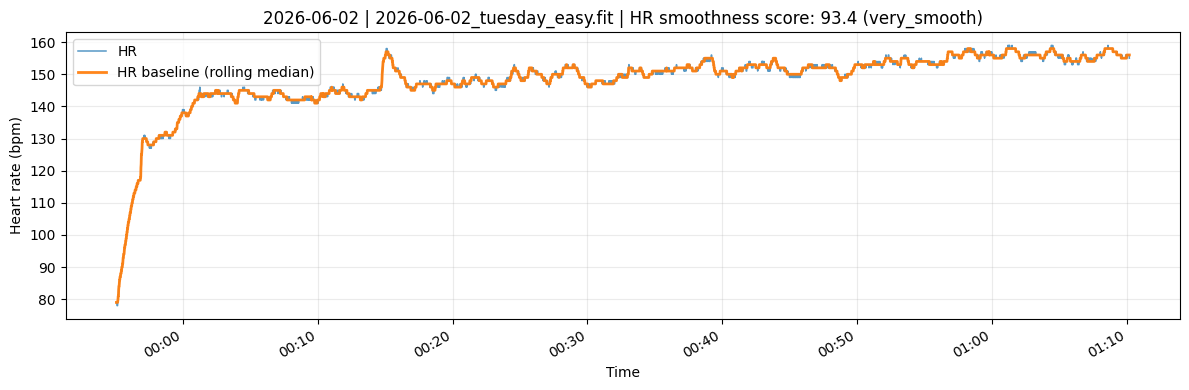

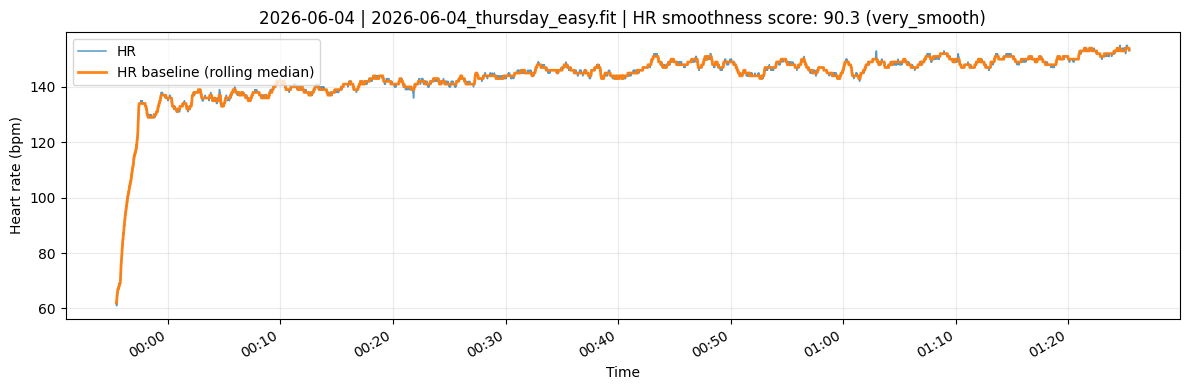

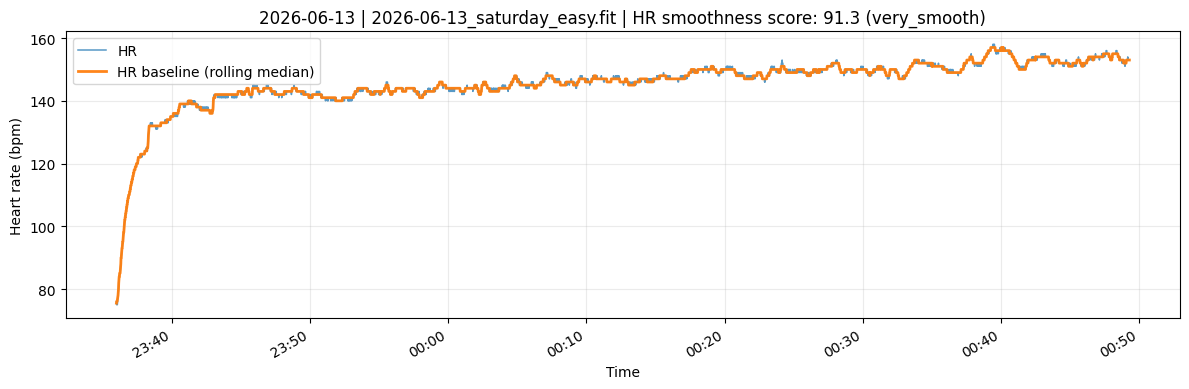

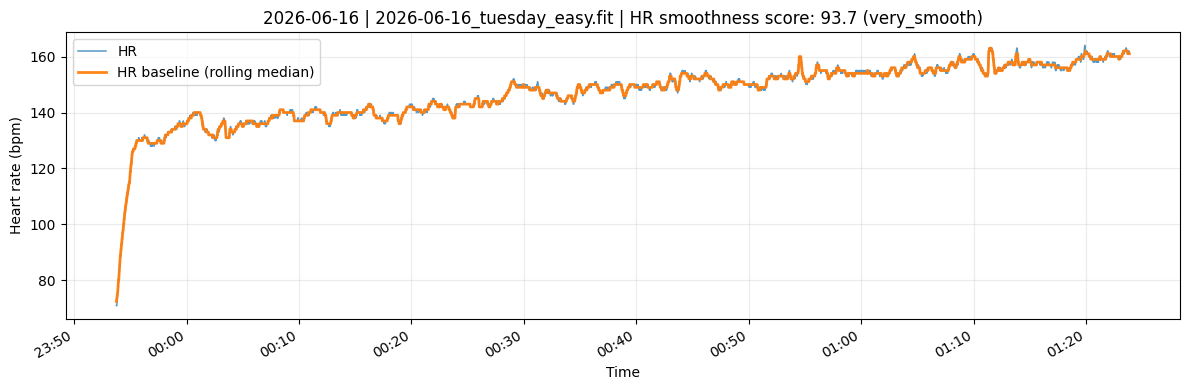

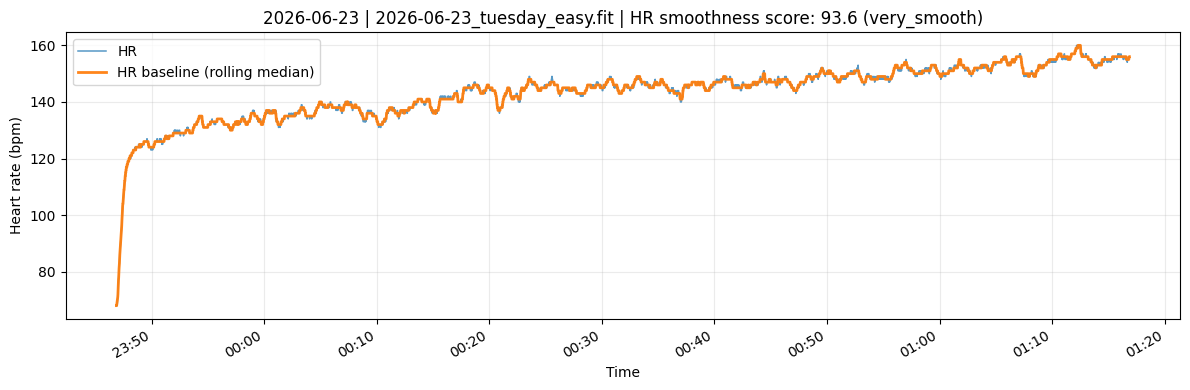

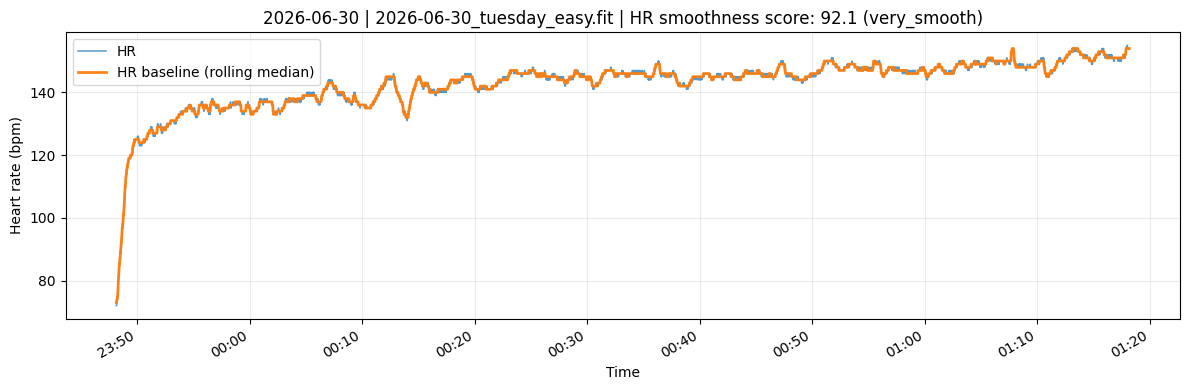

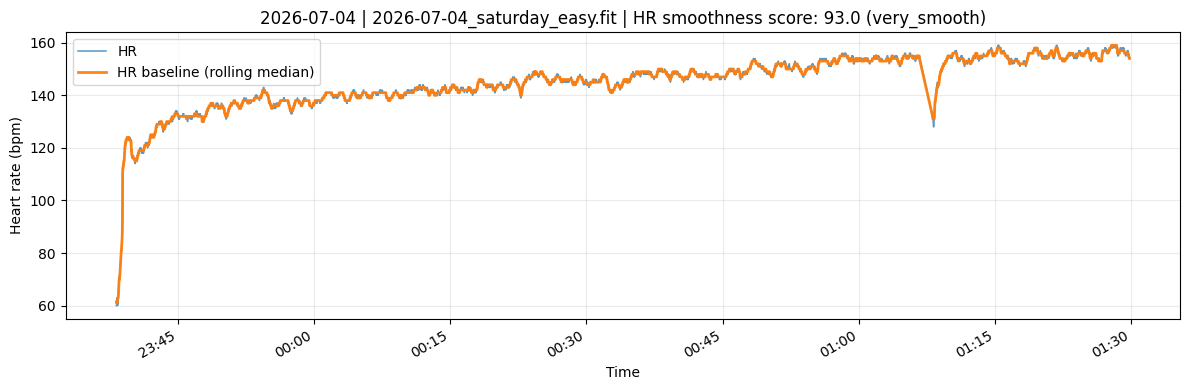

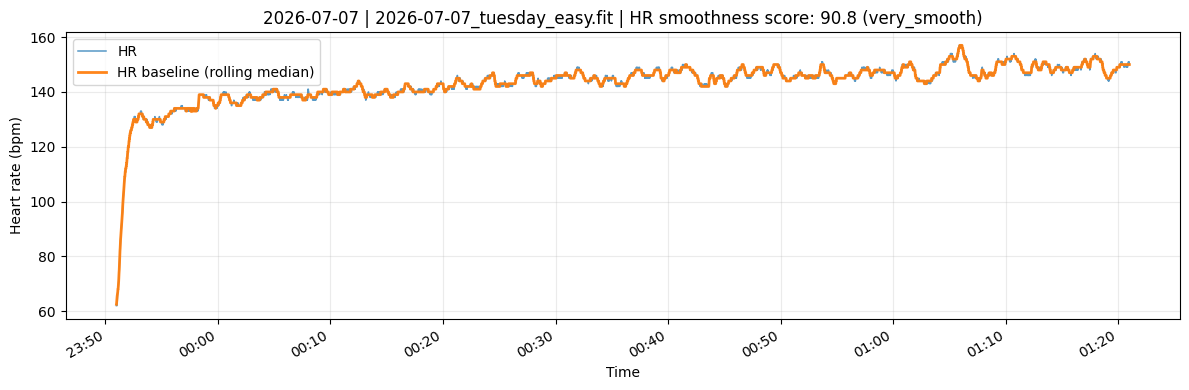

In [6]:
for run in sorted(runs, key=lambda x: x["date"]):
    rec = run["records"]
    ts = rec["timestamp"]
    hr = rec["heart_rate"]

    baseline = hr.rolling(window=15, center=True, min_periods=1).median()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ts, hr, linewidth=1.1, alpha=0.75, label="HR")
    ax.plot(ts, baseline, linewidth=2.0, alpha=0.95, label="HR baseline (rolling median)")

    score = run["hr_smoothness_score"]
    score_txt = f"{score:.1f}" if pd.notna(score) else "n/a"
    ax.set_title(
        f"{run['date'].date()} | {run['file']} | HR smoothness score: {score_txt} ({run['score_band']})"
    )
    ax.set_ylabel("Heart rate (bpm)")
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [7]:
# Optional: save daily scores to CSV for tracking.
out_csv = PROJECT_ROOT / "reports" / "easy" / "easy_run_hr_smoothness_scores.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
runs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

Saved: C:\Users\A717631\repo\theEagle\reports\easy\easy_run_hr_smoothness_scores.csv


In [8]:
# Temperature distribution vs average HR analysis
import re
from scipy.stats import pearsonr, spearmanr

def weighted_temp_from_distribution(text: str) -> float:
    if not isinstance(text, str) or text == "no_temperature_data":
        return np.nan
    parts = [p.strip() for p in text.split(",") if p.strip()]
    num = 0.0
    den = 0.0
    for part in parts:
        m = re.match(r"(-?\d+)°C:\s*([0-9.]+)%", part)
        if m:
            temp = float(m.group(1))
            pct = float(m.group(2))
            num += temp * pct
            den += pct
    return num / den if den > 0 else np.nan

analysis_df = runs_df.copy()
analysis_df["weighted_avg_temp_c"] = analysis_df["temperature_distribution"].apply(weighted_temp_from_distribution)
analysis_df["hot_fraction_pct_31plus"] = analysis_df["temperature_distribution"].apply(
    lambda s: sum(float(m.group(1)) for m in re.finditer(r"(\d+(?:\.\d+)?)%", s or "") if int(re.search(r"(\d+)°C", s[:re.search(r"(\d+(?:\.\d+)?)%", s).start()]).group(1)) >= 31)
    if isinstance(s, str) and s != "no_temperature_data" else np.nan
)

valid = analysis_df.dropna(subset=["weighted_avg_temp_c", "avg_hr_bpm"]).copy()

print(f"Runs with temperature data: {len(valid)} / {len(analysis_df)}")
if len(valid) >= 3:
    pearson_r, pearson_p = pearsonr(valid["weighted_avg_temp_c"], valid["avg_hr_bpm"])
    spearman_r, spearman_p = spearmanr(valid["weighted_avg_temp_c"], valid["avg_hr_bpm"])
    print(f"Pearson r (temp vs avg HR): {pearson_r:.3f} (p={pearson_p:.4f})")
    print(f"Spearman rho (temp vs avg HR): {spearman_r:.3f} (p={spearman_p:.4f})")
    
    # Simple slope: bpm increase per +1C
    x = valid["weighted_avg_temp_c"].to_numpy()
    y = valid["avg_hr_bpm"].to_numpy()
    slope = np.polyfit(x, y, 1)[0]
    print(f"Approx slope: {slope:.2f} bpm per +1°C")

    display_cols = ["date", "file", "weighted_avg_temp_c", "avg_hr_bpm", "temperature_distribution"]
    display(valid[display_cols].sort_values("weighted_avg_temp_c"))
else:
    print("Not enough valid runs with temperature data for correlation analysis.")

Runs with temperature data: 19 / 20
Pearson r (temp vs avg HR): 0.597 (p=0.0070)
Spearman rho (temp vs avg HR): 0.658 (p=0.0022)
Approx slope: 3.06 bpm per +1°C


,date,file,weighted_avg_temp_c,avg_hr_bpm,temperature_distribution
14,2026-06-13,2026-06-13_saturday_easy.fit,29.012000,146,"28°C: 17.0%, 29°C: 64.9%, 30°C: 18.0%, 31°C: 0.1%"
7,2026-05-09,2026-05-09_saturday_easy.fit,29.377000,147,"29°C: 64.0%, 30°C: 34.3%, 31°C: 1.7%"
16,2026-06-23,2026-06-23_tuesday_easy.fit,29.768000,143,"29°C: 46.7%, 30°C: 29.8%, 31°C: 23.5%"
19,2026-07-07,2026-07-07_tuesday_easy.fit,29.996004,143,"29°C: 16.5%, 30°C: 67.5%, 31°C: 16.1%"
17,2026-06-30,2026-06-30_tuesday_easy.fit,30.035035,143,"29°C: 8.7%, 30°C: 79.0%, 31°C: 12.2%"
6,2026-05-07,2026_05_07_thursday_easy.fit,30.041000,149,"29°C: 6.5%, 30°C: 82.9%, 31°C: 10.6%"
4,2026-04-30,2026-04-30_thursday_easy.fit,30.184000,152,"30°C: 81.6%, 31°C: 18.4%"
2,2026-04-23,2026-04-23_thursday_easy.fit,30.197000,149,"29°C: 4.0%, 30°C: 72.3%, 31°C: 23.7%"
13,2026-06-04,2026-06-04_thursday_easy.fit,30.297000,144,"29°C: 0.1%, 30°C: 70.2%, 31°C: 29.6%, 32°C: 0.1%"
12,2026-06-02,2026-06-02_tuesday_easy.fit,30.378000,148,"30°C: 62.2%, 31°C: 37.8%"


## Heat Exposure per Easy Run — Output

C:\Users\A717631\AppData\Local\Temp\ipykernel_8280\1656076234.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r')


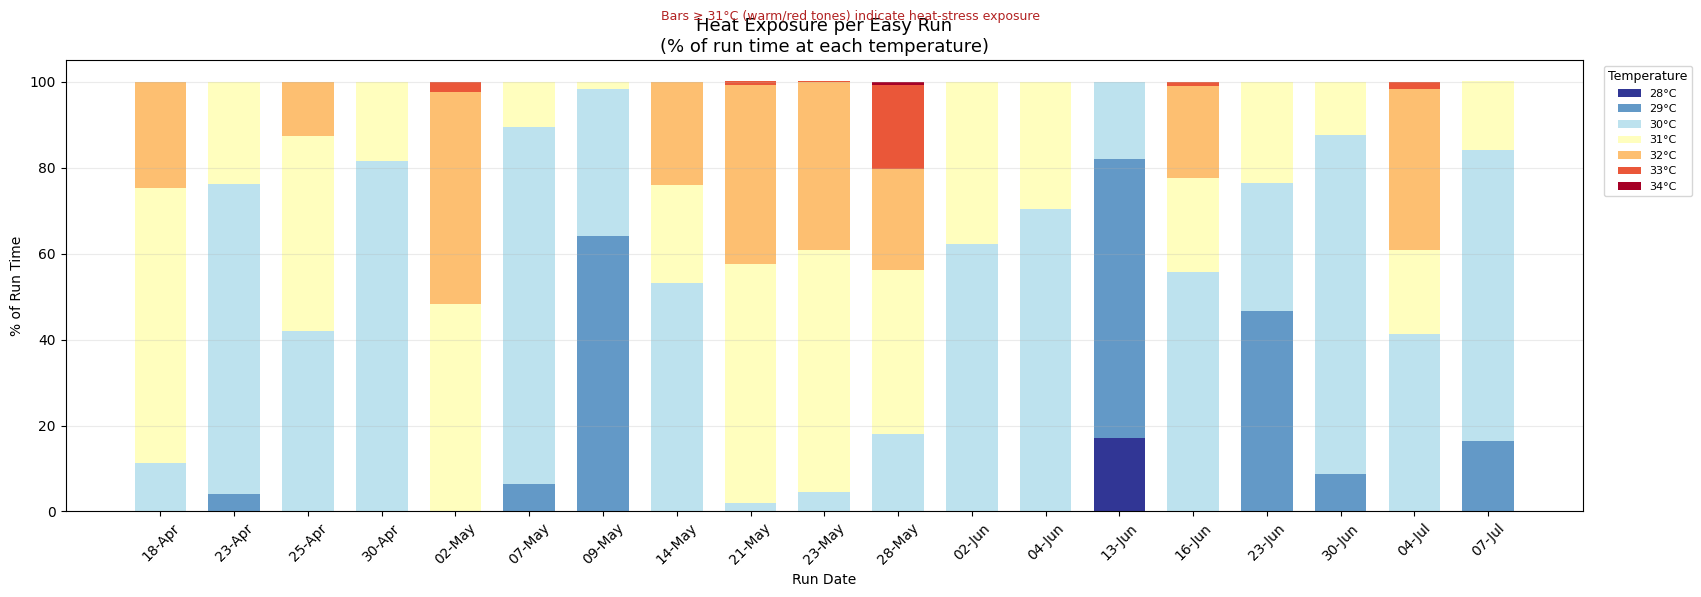

temp_c    hot_pct (≥31°C)
Run Date                 
18-Apr               88.8
23-Apr               23.7
25-Apr               58.0
30-Apr               18.4
02-May              100.0
07-May               10.6
09-May                1.7
14-May               46.9
21-May               98.1
23-May               95.6
28-May               81.9
02-Jun               37.8
04-Jun               29.7
13-Jun                0.1
16-Jun               44.3
23-Jun               23.5
30-Jun               12.2
04-Jul               58.7
07-Jul               16.1


In [9]:

# Heat Exposure Chart: time spent at each temperature bucket per run
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

if 'runs_df' not in globals() or runs_df.empty:
    print('No run summary data found. Run the summary cell first.')
else:
    heat_rows = []
    for _, row in runs_df.iterrows():
        dist = row['temperature_distribution']
        if not isinstance(dist, str) or dist == 'no_temperature_data':
            continue
        pairs = re.findall(r'(-?\d+)\s*°C:\s*([0-9.]+)%', dist)
        for temp_str, pct_str in pairs:
            heat_rows.append({
                'date': pd.to_datetime(row['date']).strftime('%d-%b'),
                'temp_c': int(temp_str),
                'pct': float(pct_str),
            })

    if not heat_rows:
        print('No temperature distribution data available.')
    else:
        heat_df = pd.DataFrame(heat_rows)
        pivot = heat_df.pivot_table(index='date', columns='temp_c', values='pct', aggfunc='sum', fill_value=0)

        # Order rows chronologically (preserve original date order from runs_df)
        date_order = [
            pd.to_datetime(d).strftime('%d-%b')
            for d in runs_df['date']
            if isinstance(runs_df.loc[runs_df['date'] == d, 'temperature_distribution'].values[0], str)
            and runs_df.loc[runs_df['date'] == d, 'temperature_distribution'].values[0] != 'no_temperature_data'
        ]
        date_order = list(dict.fromkeys(date_order))  # deduplicate while preserving order
        pivot = pivot.reindex([d for d in date_order if d in pivot.index])

        temps = pivot.columns.tolist()
        # Colour gradient: cool blue → warm red based on temperature
        norm = plt.Normalize(vmin=min(temps), vmax=max(temps))
        cmap = cm.get_cmap('RdYlBu_r')
        colours = [cmap(norm(t)) for t in temps]

        fig, ax = plt.subplots(figsize=(max(10, len(pivot) * 0.9), 6))

        bottoms = np.zeros(len(pivot))
        for temp, colour in zip(temps, colours):
            vals = pivot[temp].to_numpy(dtype=float)
            ax.bar(pivot.index, vals, bottom=bottoms, color=colour, label=f'{temp}°C', width=0.7)
            bottoms += vals

        ax.set_title('Heat Exposure per Easy Run\n(% of run time at each temperature)', fontsize=13)
        ax.set_xlabel('Run Date')
        ax.set_ylabel('% of Run Time')
        ax.set_ylim(0, 105)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.25)

        # Legend: low → high temperature, placed outside
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            title='Temperature',
            bbox_to_anchor=(1.01, 1),
            loc='upper left',
            fontsize=8,
            title_fontsize=9,
        )

        # Add a colour-bar style annotation for heat zones
        hot_threshold = 31
        ax.axhline(y=0, color='black', linewidth=0.5)
        fig.text(
            0.5, 0.97,
            f'Bars ≥ {hot_threshold}°C (warm/red tones) indicate heat-stress exposure',
            ha='center', fontsize=9, color='firebrick',
        )

        plt.tight_layout()
        plt.show()

        # Summary table
        hot_cols = [t for t in temps if t >= hot_threshold]
        pivot_display = pivot.copy()
        pivot_display['hot_pct (≥31°C)'] = pivot[hot_cols].sum(axis=1).round(1) if hot_cols else 0.0
        print(pivot_display[['hot_pct (≥31°C)']].rename_axis('Run Date').to_string())


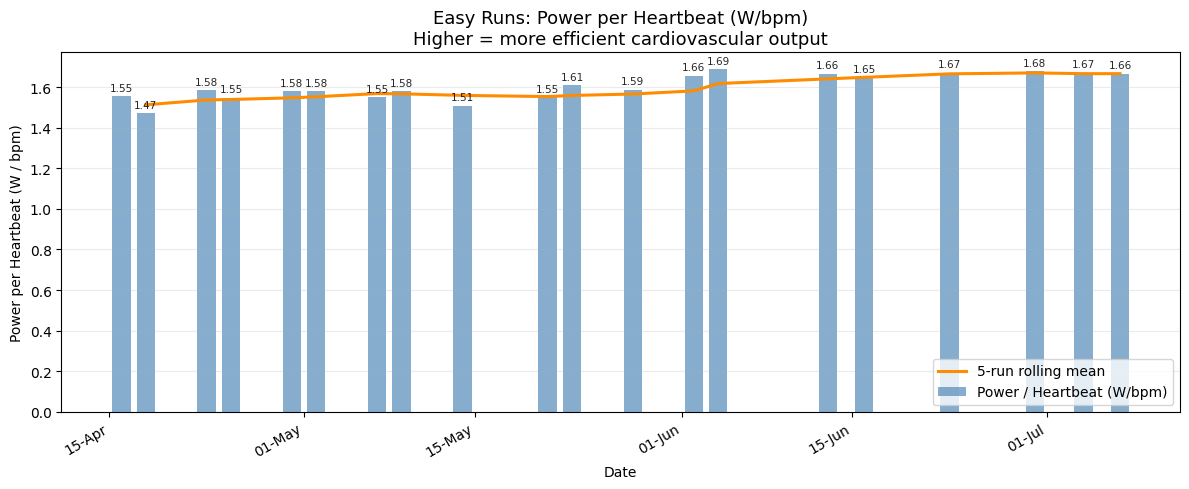

Runs plotted : 20
Latest value : 1.664 W/bpm  (2026-07-07)
Best value   : 1.688 W/bpm  (2026-06-04)
Mean         : 1.601 W/bpm
First→Last Δ : +0.110 W/bpm  (improving)


In [10]:

# Power-per-Heartbeat Chart
# Metric: avg_power (W) / avg_hr (bpm) — a proxy for cardiovascular efficiency.
# Higher value = more watts produced per heartbeat = better efficiency.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if 'runs_df' not in globals() or runs_df.empty:
    print('No run summary data found. Run the summary cell first.')
else:
    pph_df = runs_df.dropna(subset=['avg_power_w', 'avg_hr_bpm']).copy()
    pph_df = pph_df[pph_df['avg_hr_bpm'] > 0].copy()

    if pph_df.empty:
        print('No runs with both power and HR data available.')
    else:
        pph_df['power_per_beat'] = pph_df['avg_power_w'] / pph_df['avg_hr_bpm']

        dates = pd.to_datetime(pph_df['date'])
        vals = pph_df['power_per_beat'].to_numpy(dtype=float)

        # Rolling 5-run trend
        trend = pph_df['power_per_beat'].rolling(window=5, min_periods=2).mean().to_numpy()

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.bar(dates, vals, width=1.5, alpha=0.65, color='steelblue', label='Power / Heartbeat (W/bpm)')
        ax.plot(dates, trend, linewidth=2.2, color='darkorange', label='5-run rolling mean')

        # Annotate each bar with the numeric value
        for d, v in zip(dates, vals):
            ax.annotate(
                f'{v:.2f}',
                (d, v),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=7.5,
                alpha=0.85,
            )

        ax.set_title('Easy Runs: Power per Heartbeat (W/bpm)\nHigher = more efficient cardiovascular output', fontsize=13)
        ax.set_xlabel('Date')
        ax.set_ylabel('Power per Heartbeat (W / bpm)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
        fig.autofmt_xdate()
        ax.grid(axis='y', alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f'Runs plotted : {len(pph_df)}')
        print(f'Latest value : {vals[-1]:.3f} W/bpm  ({pph_df["date"].iloc[-1].date()})')
        print(f'Best value   : {vals.max():.3f} W/bpm  ({pph_df.loc[pph_df["power_per_beat"].idxmax(), "date"].date()})')
        print(f'Mean         : {vals.mean():.3f} W/bpm')
        delta = vals[-1] - vals[0]
        print(f'First→Last Δ : {delta:+.3f} W/bpm  ({"improving" if delta > 0 else "declining"})')


## Temperature Distribution vs Average HR: Documentation

This section explains how we measured the relationship between temperature and average heart rate (HR) for each easy run.

### 1) What was computed per run

For each run date, we already have:
- `avg_hr_bpm`: average heart rate for that run
- `temperature_distribution`: percentage of time spent at each rounded temperature
  - Example: `30°C: 20%, 31°C: 80%`

To convert the distribution into one numeric temperature value per run, we compute a **weighted average temperature**.

### 2) Formula

If a run has temperature bins $T_i$ (in °C) with percentages $p_i$, then:

$$
\text{WeightedAvgTemp} = \frac{\sum_i (T_i \cdot p_i)}{\sum_i p_i}
$$

Because percentages sum to ~100, this is effectively the average temperature exposure for that run.

### 3) Relationship metrics used

We evaluate the link between `WeightedAvgTemp` and `avg_hr_bpm` using:
- **Pearson correlation**: linear relationship
- **Spearman correlation**: monotonic rank relationship
- **Slope (linear fit)**: expected HR change per +1°C

### 4) Current result from this notebook run

Using runs with available temperature data (16 out of 17):
- Pearson $r = 0.660$ (p = 0.0054)
- Spearman $\rho = 0.662$ (p = 0.0052)
- Approximate slope = **+2.88 bpm per +1°C**

### 5) Easy interpretation

- The link is **moderate to strong positive** in this dataset.
- In general, warmer runs tended to show higher average HR.
- Rule-of-thumb from current data: each +1°C corresponded to about +2.9 bpm on average.

### 6) How to observe this quickly

1. Run the temperature-HR analysis cell (the one after CSV export).
2. Check Pearson/Spearman values in stdout.
3. Review the sorted table by `weighted_avg_temp_c` to confirm HR generally rises with temperature.
4. Watch for outliers (days where temperature is high but HR is lower/higher than expected).

### 7) Important caveats

- Correlation is not causation.
- HR is also influenced by pace, hydration, sleep, fatigue, terrain, and recovery status.
- One run has no temperature data (`no_temperature_data`) and is excluded from correlation.
- Re-evaluate periodically as new runs are added.